## Bringing all the png images together by labeling them a,b,c,d,e,f,g,h

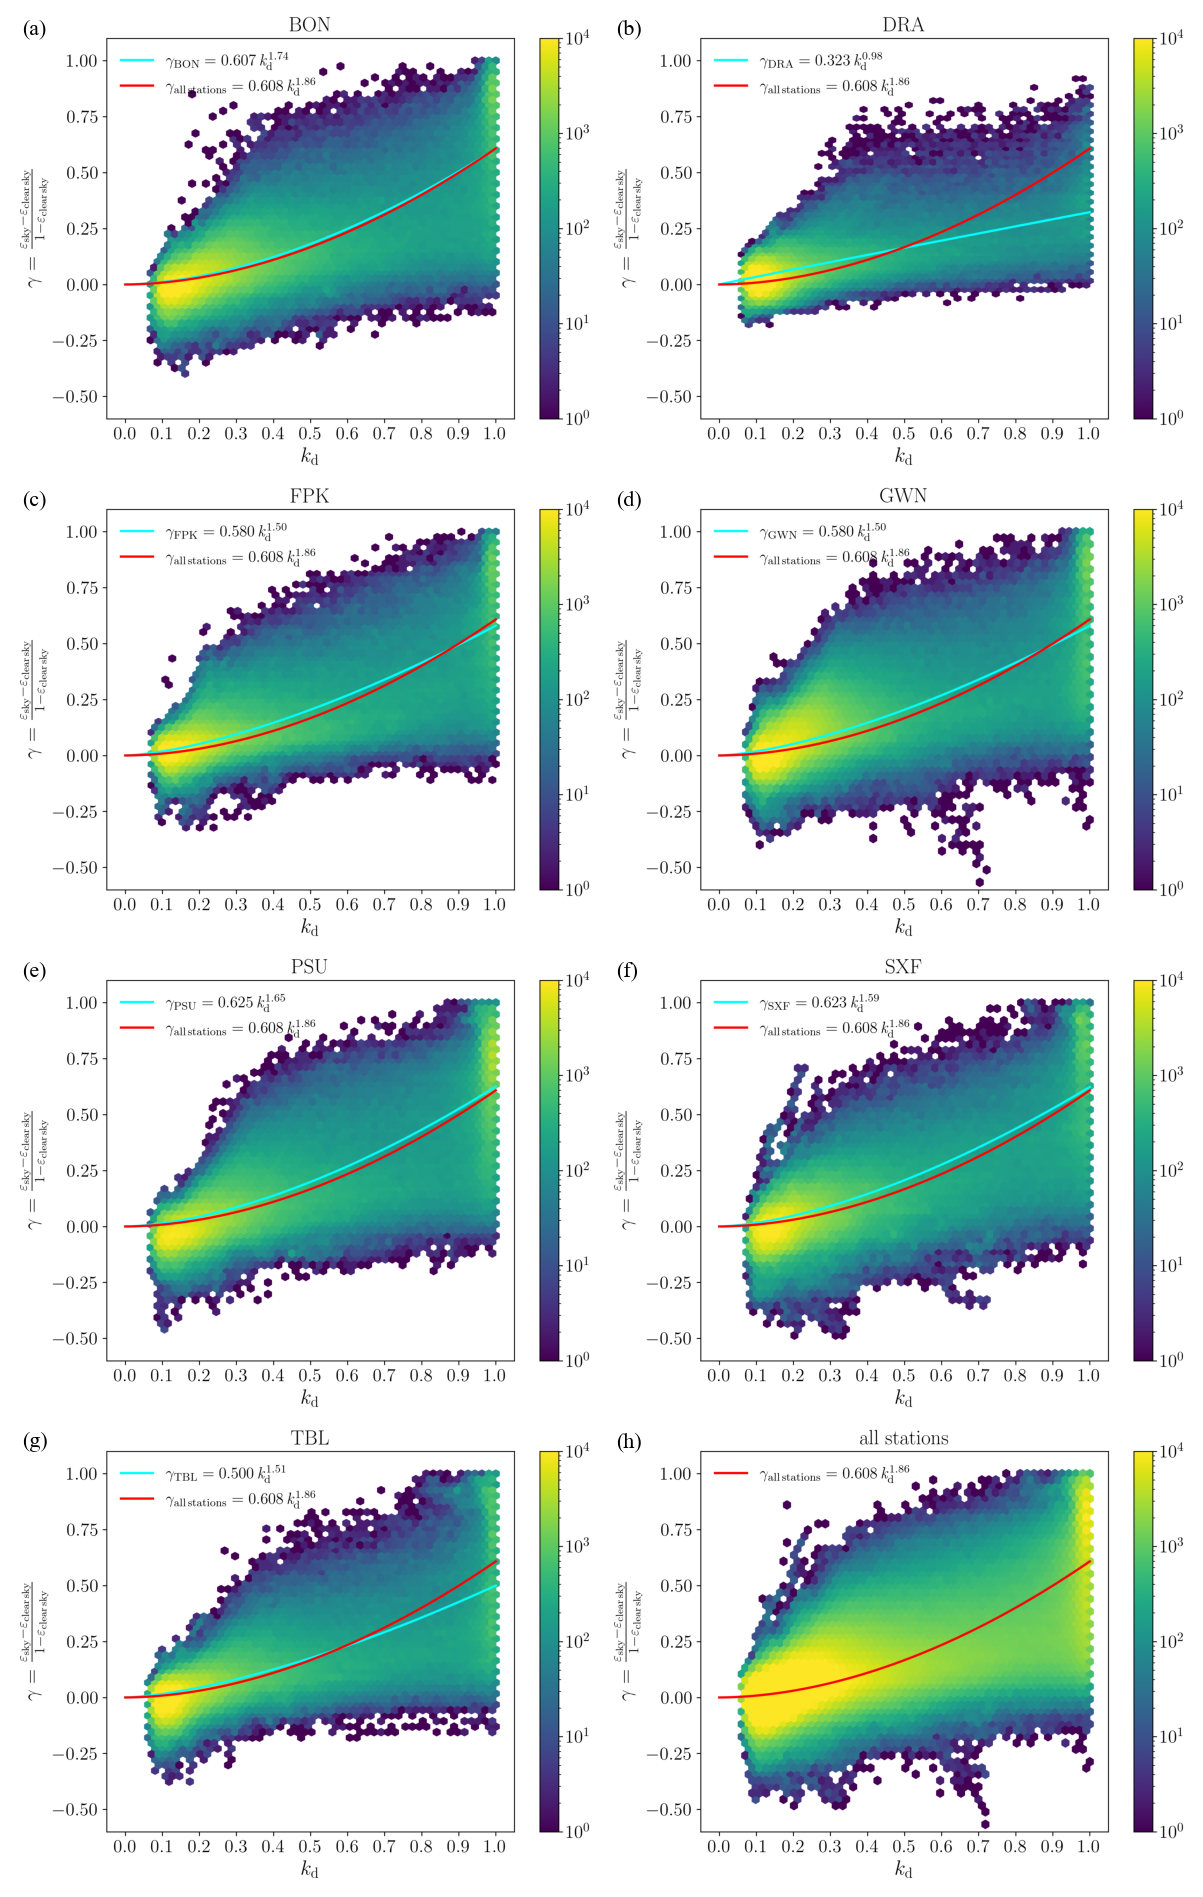

In [1]:
# Trying to bring all the pngs in this directory and plotting them in this order: BON, DRA, FPK, GWN, PSU, SXF, TBL and all stations 
import os 
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import matplotlib.font_manager as fm

# Reading all the pngs in this directory and storing their names to group them in order while showing together!
pngs = []
for file in os.listdir('.'):
    if file.endswith('.png'):
        pngs.append(file)
pngs.sort()
# Grouping the pngs in the order we want to show them
pngs_grouped = []
pngs_grouped.append([png for png in pngs if 'BON' in png])
pngs_grouped.append([png for png in pngs if 'DRA' in png])
pngs_grouped.append([png for png in pngs if 'FPK' in png])
pngs_grouped.append([png for png in pngs if 'GWN' in png])
pngs_grouped.append([png for png in pngs if 'PSU' in png])
pngs_grouped.append([png for png in pngs if 'SXF' in png])
pngs_grouped.append([png for png in pngs if 'TBL' in png])
pngs_grouped.append([png for png in pngs if 'All' in png])

# First check dimensions of an image to better set figure proportions
sample_img = mpimg.imread(pngs_grouped[0][0])
height, width, _ = sample_img.shape
aspect_ratio = width / height

# Calculate optimal figure size based on image dimensions for 4 rows, 2 columns
fig_width = 12
fig_height = fig_width / (aspect_ratio * 0.5)  # For 4 rows, 2 columns

# Create figure with 4 rows and 2 columns
fig, axs = plt.subplots(4, 2, figsize=(fig_width, fig_height))
axs = axs.flatten()  # Flatten the 2D array of axes to iterate easily

# Labels for subplots (a, b, c, etc.)
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)']

# Set font to Times New Roman
times_font = fm.FontProperties(family='Times New Roman', size=16)

# Iterate through each group and plot
for i, group in enumerate(pngs_grouped):
    if group:  # Check if the group is not empty
        img = mpimg.imread(group[0])  # Read the first image in the group
        axs[i].imshow(img)
        
        # Add the label at the top left corner with contrasting background for visibility
        axs[i].text(0.02, 0.98, labels[i], transform=axs[i].transAxes, 
                   fontproperties=times_font, va='top', ha='left', 
                   bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=3))
        
        # Turn off axes and remove existing title
        axs[i].set_title("")
        axs[i].axis('off')

# Eliminate all spacing between plots
plt.subplots_adjust(wspace=0.01, hspace=0.01)  # Minimal spacing
plt.tight_layout(pad=0.5)  # Minimal padding
plt.savefig('all_density_plots_labeled.png', dpi=300, bbox_inches='tight')
plt.show()
